<a href="https://colab.research.google.com/github/Anusri-J/Brain-Tumor-MRI-Image-Classification/blob/main/Brain_Tumor_MRI_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import pandas as pd
import tensorflow as tf

# Path to dataset
DATA_DIR= "/content/drive/MyDrive/Tumour"


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

# ✅ Load datasets
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{DATA_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{DATA_DIR}/valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{DATA_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ✅ Class names
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

Found 1689 files belonging to 4 classes.
Found 499 files belonging to 4 classes.
Found 246 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']


**Data Normalization and Augmentation**

In [4]:
# Normalization and augmentation
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.12),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

# Dataset preparation function
def prepare(ds, augment=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.cache().prefetch(buffer_size=AUTOTUNE)

# Apply preprocessing
train_ds_prepared = prepare(train_ds, augment=True)
valid_ds_prepared = prepare(valid_ds, augment=False)
test_ds_prepared = prepare(test_ds, augment=False)

**Custom CNN Model**

In [5]:
from tensorflow.keras import layers, models

def build_custom_cnn(input_shape=(224,224,3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = normalization_layer(x)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="Custom_CNN")
    return model

custom_model = build_custom_cnn()
custom_model.summary(
)

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,260 (1.62 MB)

 Trainable params: 423,044 (1.61 MB)

 Non-trainable params: 1,216 (4.75 KB)

**Transfer Learning (EfficientNetB0)**

In [6]:
from tensorflow.keras.applications import EfficientNetB0

def build_transfer_model(input_shape=(224,224,3), num_classes=NUM_CLASSES):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape, pooling='avg')
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = normalization_layer(x)
    x = base_model(x, training=False)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name="EfficientNetB0_transfer")
    return model, base_model

eff_model, eff_base = build_transfer_model()
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

**Define Callbacks**

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    'best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1
)

**Train & Evaluate Custom CNN**

In [11]:
custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Training Custom CNN...")
history_custom = custom_model.fit(
    train_ds_prepared,
    validation_data=valid_ds_prepared,
    epochs=25,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

# Evaluate
custom_loss, custom_acc = custom_model.evaluate(test_ds_prepared)
print(f"✅ Custom CNN Test Accuracy: {custom_acc:.4f}")


🚀 Training Custom CNN...
Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.6477 - loss: 0.9891
Epoch 1: val_accuracy improved from -inf to 0.32265, saving model to best_model.h5


53/53 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6475 - loss: 0.9898 - val_accuracy: 0.3226 - val_loss: 1.4179 - learning_rate: 1.0000e-04
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.6545 - loss: 0.9086
Epoch 2: val_accuracy did not improve from 0.32265
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.6543 - loss: 0.9089 - val_accuracy: 0.3226 - val_loss: 1.5310 - learning_rate: 1.0000e-04
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6629 - loss: 0.8669
Epoch 3: val_accuracy did not improve from 0.32265
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.6629 - loss: 0.8672 - val_accuracy: 0.3226 - val_loss: 1.7413 - learning_rate: 1.0000e-04
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.6649 - loss: 0.8806
Epoch 4: val_accuracy did not improve from 0.32265

Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.6649 - loss: 0.8810 - v

**Train & Evaluate EfficientNetB0 Model**

In [12]:
eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n🚀 Training EfficientNetB0 Transfer Model...")
history_eff = eff_model.fit(
    train_ds_prepared,
    validation_data=valid_ds_prepared,
    epochs=25,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

# Evaluate
eff_loss, eff_acc = eff_model.evaluate(test_ds_prepared)
print(f"✅ EfficientNetB0 Test Accuracy: {eff_acc:.4f}")


🚀 Training EfficientNetB0 Transfer Model...
Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2263 - loss: 2.1024
Epoch 1: val_accuracy did not improve from 0.32265
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 189ms/step - accuracy: 0.2265 - loss: 2.1010 - val_accuracy: 0.2305 - val_loss: 1.3971 - learning_rate: 1.0000e-04
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.2481 - loss: 1.8995
Epoch 2: val_accuracy did not improve from 0.32265
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.2481 - loss: 1.8997 - val_accuracy: 0.3226 - val_loss: 1.3810 - learning_rate: 1.0000e-04
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.2471 - loss: 1.9055
Epoch 3: val_accuracy did not improve from 0.32265
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.2473 - loss: 1.9050 - val_accuracy: 0.3226 - val_loss: 1.3764 - learning_rate: 1.0000e-04
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.2685 - loss: 1.7636
Epoch 4: val_accuracy did n

In [13]:
custom_model.save("custom_cnn_model.keras")
eff_model.save("efficientnetb0_model.keras")

**Evaluate models**

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Get true labels and predictions
y_true = np.concatenate([y for x, y in test_ds_prepared], axis=0)
y_pred_custom = np.argmax(custom_model.predict(test_ds_prepared), axis=1)
y_pred_eff = np.argmax(eff_model.predict(test_ds_prepared), axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step


In [16]:
# ✅ Classification report
print("📊 Custom CNN Performance:")
print(classification_report(y_true, y_pred_custom, target_names=class_names))

📊 Custom CNN Performance:
              precision    recall  f1-score   support

      glioma       0.33      1.00      0.49        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.33       246
   macro avg       0.08      0.25      0.12       246
weighted avg       0.11      0.33      0.16       246



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
print("📊 EfficientNetB0 Performance:")
print(classification_report(y_true, y_pred_eff, target_names=class_names))

📊 EfficientNetB0 Performance:
              precision    recall  f1-score   support

      glioma       0.33      1.00      0.49        80
  meningioma       0.00      0.00      0.00        63
    no_tumor       0.00      0.00      0.00        49
   pituitary       0.00      0.00      0.00        54

    accuracy                           0.33       246
   macro avg       0.08      0.25      0.12       246
weighted avg       0.11      0.33      0.16       246



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


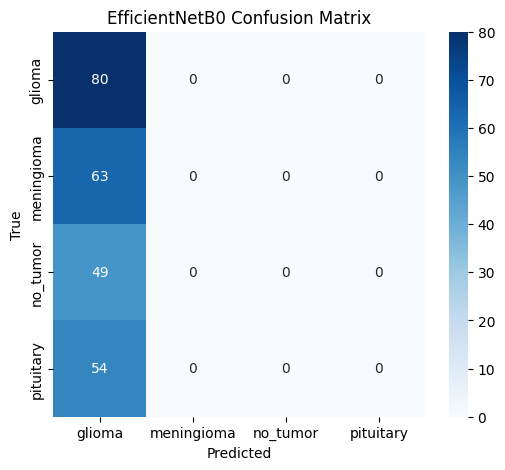

In [18]:
# ✅ Confusion Matrix for EfficientNetB0
cm = confusion_matrix(y_true, y_pred_eff)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("EfficientNetB0 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

**Visualize Training Performance**

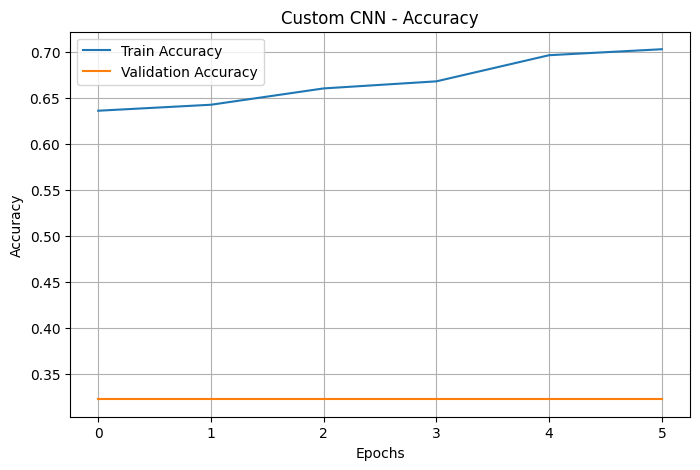

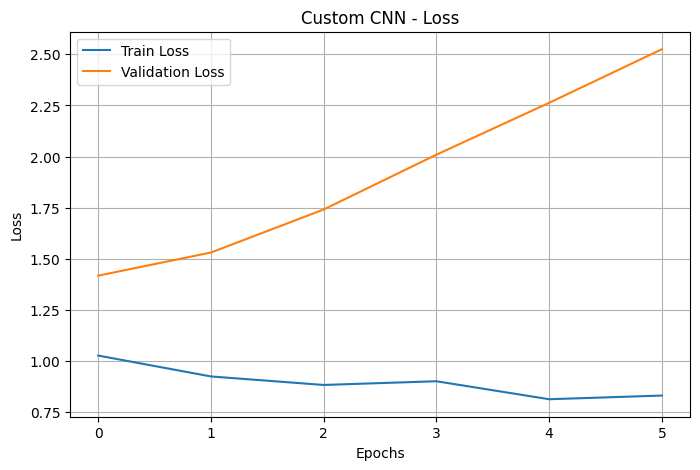

In [19]:
import matplotlib.pyplot as plt

# Function to plot accuracy separately
def plot_accuracy(history, title):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to plot loss separately
def plot_loss(history, title):
    plt.figure(figsize=(8,5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot for Custom CNN
plot_accuracy(history_custom, "Custom CNN")
plot_loss(history_custom, "Custom CNN")

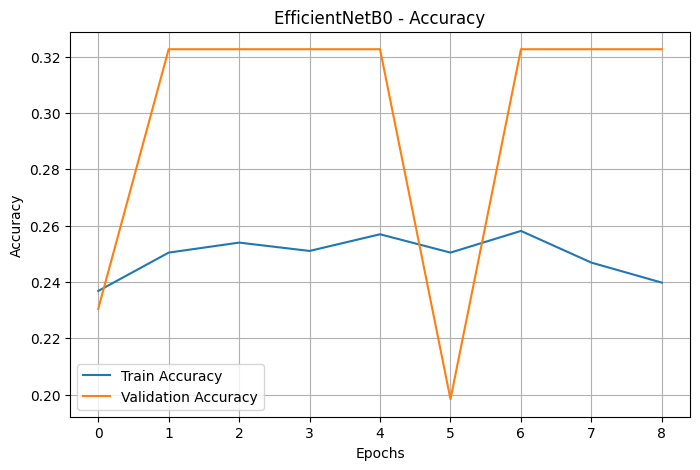

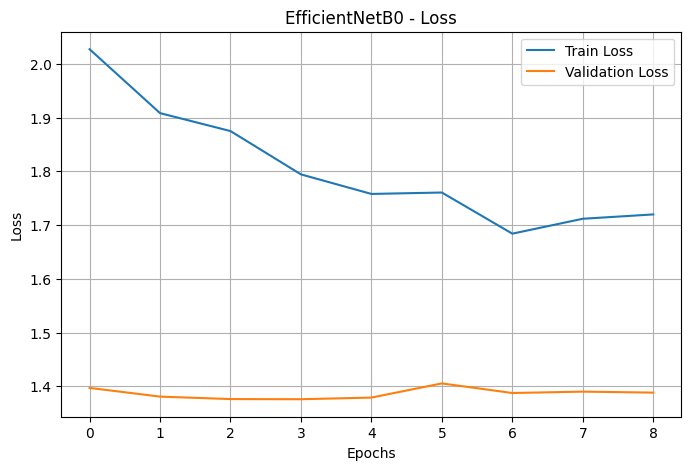

In [20]:
# Plot for EfficientNetB0
plot_accuracy(history_eff, "EfficientNetB0")
plot_loss(history_eff, "EfficientNetB0")

**🧠 Model Comparison Section**

**Compare Training & Validation Accuracy**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


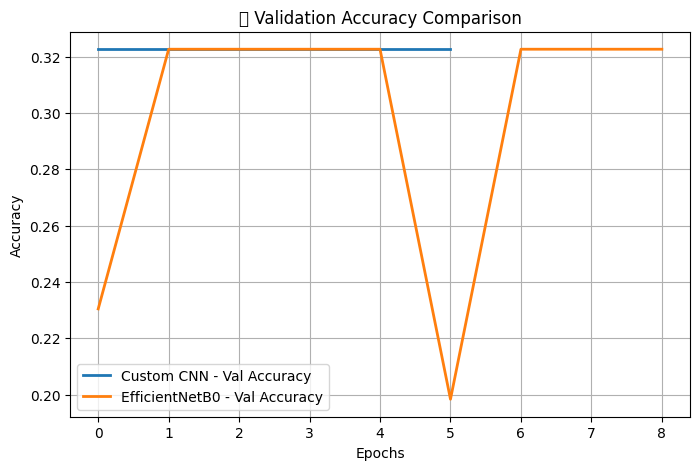

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_custom.history['val_accuracy'], label='Custom CNN - Val Accuracy', linewidth=2)
plt.plot(history_eff.history['val_accuracy'], label='EfficientNetB0 - Val Accuracy', linewidth=2)
plt.title('📈 Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

**Compare Training & Validation Loss**

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


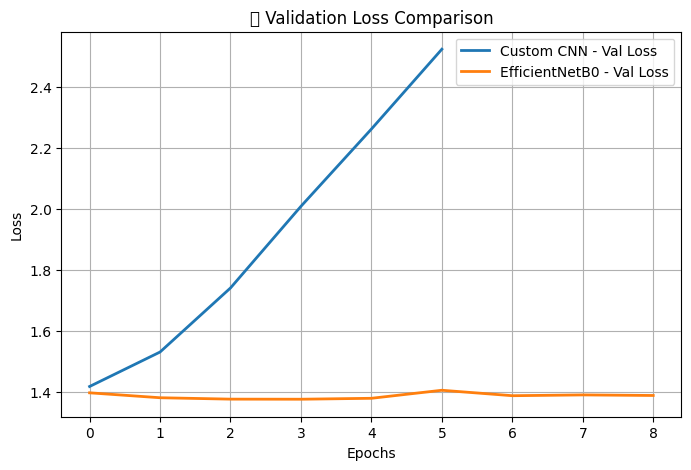

In [22]:
plt.figure(figsize=(8,5))
plt.plot(history_custom.history['val_loss'], label='Custom CNN - Val Loss', linewidth=2)
plt.plot(history_eff.history['val_loss'], label='EfficientNetB0 - Val Loss', linewidth=2)
plt.title('📉 Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Numerical Comparison**

In [23]:
custom_loss, custom_acc = custom_model.evaluate(test_ds_prepared)
eff_loss, eff_acc = eff_model.evaluate(test_ds_prepared)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5981 - loss: 1.2702
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.5981 - loss: 1.2818


In [24]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': ['Custom CNN', 'EfficientNetB0'],
    'Test Accuracy': [custom_acc, eff_acc],
    'Test Loss': [custom_loss, eff_loss]
})

print("📊 Model Performance Comparison:")
print(comparison_df)

📊 Model Performance Comparison:
            Model  Test Accuracy  Test Loss
0      Custom CNN       0.325203   1.422958
1  EfficientNetB0       0.325203   1.375320


**Identify Best Model**

In [25]:
best_model = "Custom CNN" if custom_acc > eff_acc else "EfficientNetB0"
print(f"\n🏆 Best Performing Model: {best_model}")

if best_model == "EfficientNetB0":
    print("✅ EfficientNetB0 shows higher validation accuracy and generalization capability.")
else:
    print("✅ Custom CNN performs better — simpler yet effective architecture.")


🏆 Best Performing Model: EfficientNetB0
✅ EfficientNetB0 shows higher validation accuracy and generalization capability.


In [26]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 112.6 MB/s eta 0:00:00
--2025-10-30 10:51:12--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2025.10.0/cloudflared-linux-amd64 [following]
--2025-10-30 10:51:12--  https://github.com/cloudflare/cloudflared/releases/download/2025.10.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/3cf4ee00-005b-4d19-8b1e-15145bd129bf?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-10-30T11%3A48%3A36Z&rscd=attachment%3B+filen

In [27]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image, ImageOps
import io
import os

st.set_page_config(page_title="🧠 Brain Tumor Classifier", layout="centered")

# -----------------------------
# Config / Constants
# -----------------------------
DEFAULT_IMG_SIZE = (224, 224)
CLASS_NAMES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']  # keep in same order used during training
MODEL_FILES_TO_TRY = {
    "Custom CNN": ["custom_cnn_model.keras", "custom_cnn_model.h5", "best_custom_cnn.keras", "best_custom_cnn.h5"],
    "EfficientNetB0": ["efficientnetb0_model.keras", "efficientnetb0_model.h5", "best_effnetb0.keras", "best_effnetb0.h5"]
}

# -----------------------------
# Utility functions
# -----------------------------
def find_model_file(possible_names):
    """Return first existing model path from possible_names or None."""
    for name in possible_names:
        if os.path.exists(name):
            return name
    return None

@st.cache_resource
def load_models():
    """Attempt to load both models from disk; return dict of (name -> model or None)."""
    loaded = {}
    for label, candidates in MODEL_FILES_TO_TRY.items():
        path = find_model_file(candidates)
        if path is None:
            loaded[label] = None
        else:
            try:
                loaded[label] = tf.keras.models.load_model(path)
            except Exception as e:
                st.warning(f"Could not load {label} from {path}: {e}")
                loaded[label] = None
    return loaded

def preprocess_pil_image(pil_img, img_size=DEFAULT_IMG_SIZE):
    """Resize, convert to RGB, scale to [0,1] and return batch of shape (1,H,W,3)."""
    img = pil_img.convert("RGB")
    img = ImageOps.fit(img, img_size, Image.Resampling.BILINEAR)
    arr = np.asarray(img).astype(np.float32) / 255.0
    return np.expand_dims(arr, axis=0)

def predict_with_model(model, img_batch):
    """Return (pred_class_idx, probs_array) given a compiled keras model and preprocessed batch."""
    preds = model.predict(img_batch)  # shape (1, num_classes)
    probs = preds[0]
    idx = int(np.argmax(probs))
    return idx, probs

# -----------------------------
# Sidebar / Info
# -----------------------------
st.sidebar.title("ℹ️ Project")
st.sidebar.markdown(
    """
**Brain Tumor Classifier**
Upload a brain MRI image and choose a model to get a tumor type prediction and confidence.
- Custom CNN: model trained from scratch
- EfficientNetB0: transfer learning baseline
"""
)
st.sidebar.markdown("**Model files expected:** `custom_cnn_model.keras` / `efficientnetb0_model.keras` (or `.h5`).")
st.sidebar.markdown("---")

# -----------------------------
# Load models
# -----------------------------
models_dict = load_models()
available_models = [k for k,v in models_dict.items() if v is not None]
if not available_models:
    st.sidebar.error("No models found on disk. Put model files in the same folder (see sidebar).")
else:
    st.sidebar.success(f"Loaded models: {', '.join(available_models)}")

# -----------------------------
# App Title / Upload
# -----------------------------
st.title("🧠 Brain Tumor MRI Classifier")
st.write("Upload a brain MRI image. The app will display the predicted tumor type and model confidence.")

uploaded_file = st.file_uploader("Upload MRI image (jpg / jpeg / png)", type=["jpg","jpeg","png"])

# Choose model
model_choice = st.selectbox("Choose model", ["Select a model"] + list(MODEL_FILES_TO_TRY.keys()))
model_selected = models_dict.get(model_choice) if model_choice != "Select a model" else None

# Option to show raw probabilities as table
show_probs = st.checkbox("Show class probabilities", value=True)

# Predict button area
if uploaded_file is not None:
    try:
        image = Image.open(io.BytesIO(uploaded_file.read()))
    except Exception as e:
        st.error("Could not read image. Try a different file.")
        st.stop()

    st.image(image, caption="Uploaded Image", use_column_width=True)

    if model_choice == "Select a model":
        st.warning("Please select a model to perform prediction.")
    elif model_selected is None:
        st.error(f"Selected model `{model_choice}` is not available / failed to load. Check model files.")
    else:
        # Preprocess and predict
        img_batch = preprocess_pil_image(image, img_size=DEFAULT_IMG_SIZE)
        with st.spinner("Predicting..."):
            pred_idx, probs = predict_with_model(model_selected, img_batch)

        pred_label = CLASS_NAMES[pred_idx]
        confidence = float(probs[pred_idx]) * 100.0

        st.success(f"🎯 Predicted tumor type: **{pred_label}**")
        st.info(f"Confidence: **{confidence:.2f}%**")

        if show_probs:
            # Show probabilities sorted
            prob_df = {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}
            # order descending
            prob_items = sorted(prob_df.items(), key=lambda x: x[1], reverse=True)
            st.write("### Class probabilities")
            # Display as bar chart
            labels = [p[0] for p in prob_items]
            values = [p[1] for p in prob_items]
            st.bar_chart(data={ "probability": np.array(values) }, use_container_width=True)
            # Also show a table
            st.table({ "Class": labels, "Probability": [f"{v*100:.2f}%" for v in values] })

        # Optional: Download predicted image with overlay text
        if st.button("Download result image"):
            # create simple annotated image
            img_copy = image.convert("RGB").resize(DEFAULT_IMG_SIZE, Image.Resampling.BILINEAR)
            try:
                from PIL import ImageDraw, ImageFont
                draw = ImageDraw.Draw(img_copy)
                # default font
                try:
                    font = ImageFont.truetype("DejaVuSans.ttf", 18)
                except Exception:
                    font = ImageFont.load_default()
                text = f"{pred_label} ({confidence:.1f}%)"
                draw.rectangle([0, 0, img_copy.width, 28], fill=(0,0,0,127))
                draw.text((6,4), text, fill=(255,255,255), font=font)
            except Exception:
                pass

            buf = io.BytesIO()
            img_copy.save(buf, format="PNG")
            buf.seek(0)
            st.download_button("Click to download annotated image", data=buf, file_name="prediction.png", mime="image/png")

# Footer / credits
st.markdown("---")
st.markdown("Built for demonstration — use in clinical practice only after rigorous validation. ⚠️")

Writing app.py


In [28]:
!streamlit run /content/app.py &>/content/logs.txt &

In [29]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://handheld-evanescence-lighter-fabrics.trycloudflare.com
